In [2]:
%pip install opencv-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Largura do marcador: 465 pixels
Altura do marcador: 526 pixels


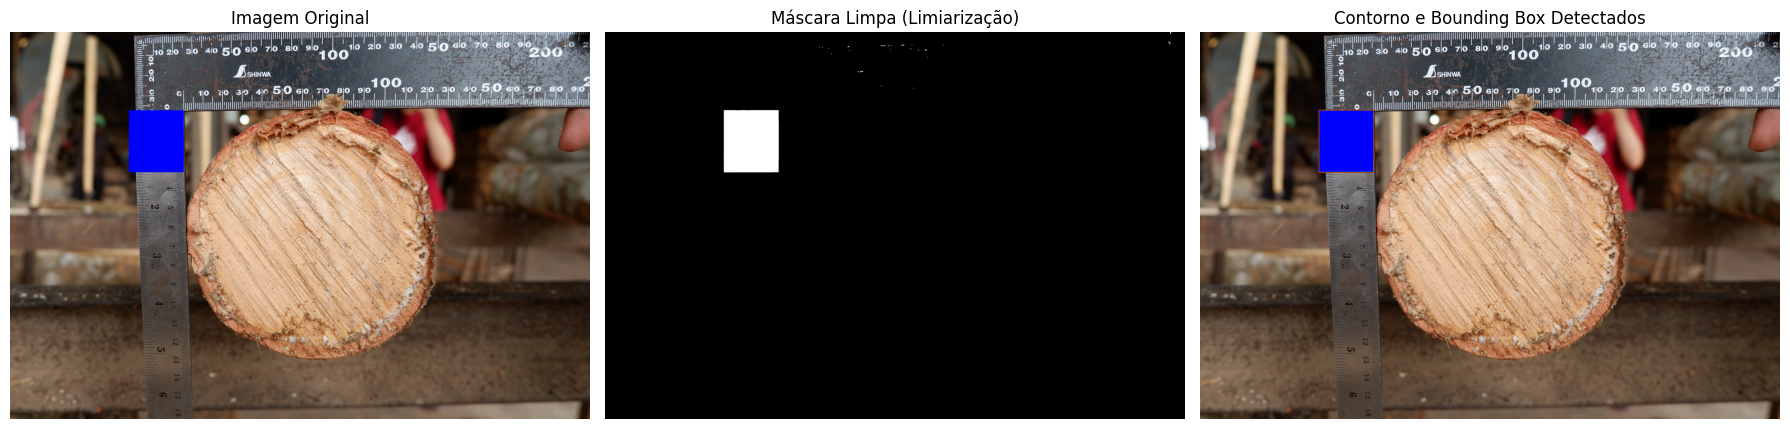

In [3]:
# 1. Buscar a primeira imagem disponível no dataset

caminho_imagens = glob.glob("../data/raw/train/images/*.jpg")
if not caminho_imagens:
    print("Nenhuma imagem encontrada. Verifique o caminho.")
else:
    img_path = caminho_imagens[0]
    
    # 2. Carregar a imagem
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 3. Converter para o espaço HSV (Matiz, Saturação, Valor)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # 4. Definir os limites da cor AZUL no OpenCV
    # O Matiz (Hue) do azul no OpenCV fica em torno de 100 a 130
    limite_inferior = np.array([100, 100, 50])
    limite_superior = np.array([130, 255, 255])
    
    # 5. Criar a máscara: pixels dentro do limite viram branco (255), o resto vira preto (0)
    mascara = cv2.inRange(hsv, limite_inferior, limite_superior)
    
    # 6. Operações Morfológicas (Limpeza de ruídos)
    # Remove pequenos pontos azuis que não são o marcador
    kernel = np.ones((5,5), np.uint8)
    mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)
    
    # 7. Encontrar os contornos na máscara limpa
    contornos, _ = cv2.findContours(mascara_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Desenhar o maior contorno encontrado na imagem original para visualização
    img_resultado = img_rgb.copy()
    if contornos:
        # Pega o maior contorno (assumindo que o marcador azul é a maior mancha azul)
        maior_contorno = max(contornos, key=cv2.contourArea)
        cv2.drawContours(img_resultado, [maior_contorno], -1, (0, 255, 0), 5)
        
        # Calcular a área e o bounding box
        x, y, w, h = cv2.boundingRect(maior_contorno)
        cv2.rectangle(img_resultado, (x, y), (x+w, y+h), (255, 0, 0), 3)
        print(f"Largura do marcador: {w} pixels")
        print(f"Altura do marcador: {h} pixels")
    
    # 8. Plotar os resultados lado a lado
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    ax[0].imshow(img_rgb)
    ax[0].set_title("Imagem Original")
    ax[0].axis('off')
    
    ax[1].imshow(mascara_limpa, cmap='gray')
    ax[1].set_title("Máscara Limpa (Limiarização)")
    ax[1].axis('off')
    
    ax[2].imshow(img_resultado)
    ax[2].set_title("Contorno e Bounding Box Detectados")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()